📦 Total de amostras: 44996

=== 1) SANITY CHECK ===
sample_00000.npz | LiDAR shape=(360,) | Pose=[-3.60956     0.76312697  0.10193777]
sample_00001.npz | LiDAR shape=(360,) | Pose=[-3.6095731   0.7631267   0.10220475]
sample_00002.npz | LiDAR shape=(360,) | Pose=[-3.609576    0.76312655  0.1022146 ]
sample_00003.npz | LiDAR shape=(360,) | Pose=[-3.6095743   0.7631266   0.10217229]
sample_00004.npz | LiDAR shape=(360,) | Pose=[-3.6095717   0.7631267   0.10212634]
✅ Shapes consistentes

=== 2) RANGE & NaN CHECK ===
LiDAR min = 0.009, max = 1.000
NaN / Inf encontrados? False

=== 3) COBERTURA ESPACIAL ===


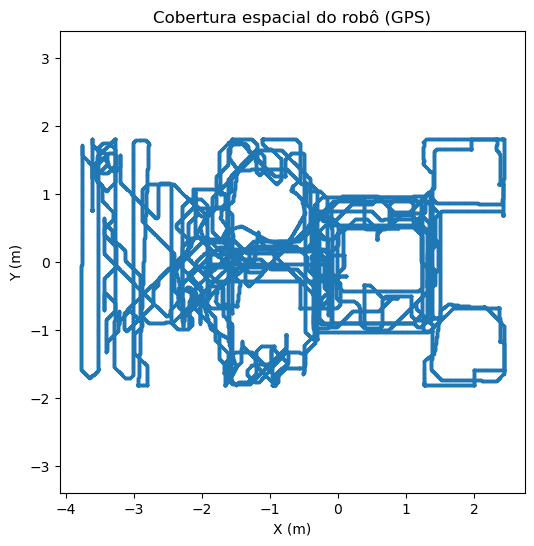


=== 4) VARIAÇÃO TEMPORAL DO LiDAR ===
Δ médio = 0.0031
Δ mínimo = 0.0000
Δ máximo = 0.0370


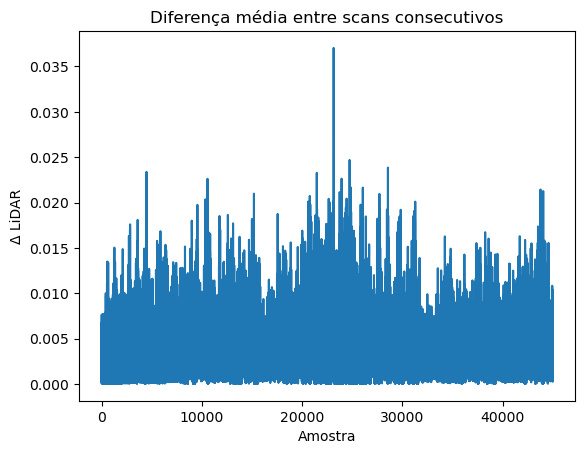


=== 5) AMBIGUIDADE GEOMÉTRICA (testes aleatórios) ===
Scan Δ=0.2702 | Pose dist=3.56 m
Scan Δ=0.2484 | Pose dist=3.88 m
Scan Δ=0.4016 | Pose dist=3.44 m
Scan Δ=0.1078 | Pose dist=0.39 m
Scan Δ=0.2324 | Pose dist=3.47 m

=== 6) VISUALIZAÇÃO DE SCANS ===


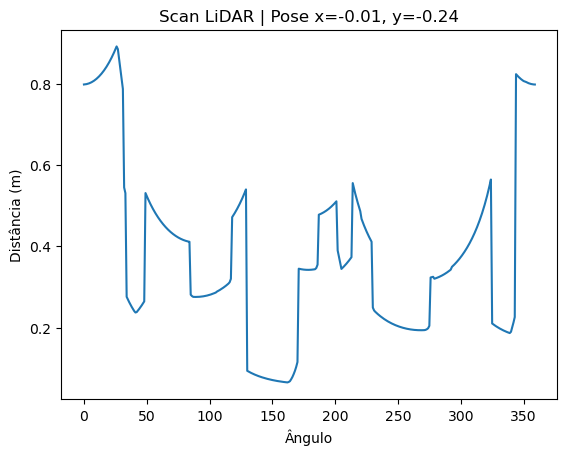


=== 7) RESUMO FINAL ===
✔️ Dataset carregável
✔️ Cobertura espacial visível
✔️ Variação temporal medida
✔️ Ambiguidade avaliada

👉 Se houver boa cobertura + Δ razoável, o dataset é treinável.


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import random

# ==========================================================
# CONFIG
# ==========================================================
DATASET_DIR = Path(
    r"C:\Users\User\Documents\IA_PROJECT\Archives\Trabalho_IA_2025\files_webot\IA_20252\controllers\lidar_dataset\dataset_lidar_pose"
)

MAX_SAMPLES_PRINT = 5
RANDOM_TESTS = 5

# ==========================================================
# LOAD FILES
# ==========================================================
files = sorted(DATASET_DIR.glob("*.npz"))
assert len(files) > 0, "❌ Nenhum arquivo .npz encontrado!"

print(f"📦 Total de amostras: {len(files)}")

# ==========================================================
# 1️⃣ SANITY CHECK
# ==========================================================
print("\n=== 1) SANITY CHECK ===")

shapes = set()
for f in files[:MAX_SAMPLES_PRINT]:
    d = np.load(f)
    lidar = d["lidar"]
    pose = d["pose"]

    shapes.add(lidar.shape)
    print(f"{f.name} | LiDAR shape={lidar.shape} | Pose={pose}")

assert len(shapes) == 1, "❌ Shapes diferentes de LiDAR detectados!"
print("✅ Shapes consistentes")

# ==========================================================
# 2️⃣ RANGE / NaN CHECK
# ==========================================================
print("\n=== 2) RANGE & NaN CHECK ===")

all_min, all_max = float("inf"), -float("inf")
nan_found = False

for f in files:
    scan = np.load(f)["lidar"]
    all_min = min(all_min, scan.min())
    all_max = max(all_max, scan.max())
    if np.isnan(scan).any() or np.isinf(scan).any():
        nan_found = True

print(f"LiDAR min = {all_min:.3f}, max = {all_max:.3f}")
print("NaN / Inf encontrados?" , nan_found)

# ==========================================================
# 3️⃣ COBERTURA ESPACIAL
# ==========================================================
print("\n=== 3) COBERTURA ESPACIAL ===")

xs, ys = [], []
for f in files:
    pose = np.load(f)["pose"]
    xs.append(pose[0])
    ys.append(pose[1])

plt.figure(figsize=(6,6))
plt.scatter(xs, ys, s=2)
plt.axis("equal")
plt.title("Cobertura espacial do robô (GPS)")
plt.xlabel("X (m)")
plt.ylabel("Y (m)")
plt.show()

# ==========================================================
# 4️⃣ VARIAÇÃO TEMPORAL DO LiDAR
# ==========================================================
print("\n=== 4) VARIAÇÃO TEMPORAL DO LiDAR ===")

deltas = []
for i in range(1, len(files)):
    a = np.load(files[i-1])["lidar"]
    b = np.load(files[i])["lidar"]
    deltas.append(np.mean(np.abs(b - a)))

deltas = np.array(deltas)

print(f"Δ médio = {deltas.mean():.4f}")
print(f"Δ mínimo = {deltas.min():.4f}")
print(f"Δ máximo = {deltas.max():.4f}")

plt.figure()
plt.plot(deltas)
plt.title("Diferença média entre scans consecutivos")
plt.xlabel("Amostra")
plt.ylabel("Δ LiDAR")
plt.show()

# ==========================================================
# 5️⃣ AMBIGUIDADE GEOMÉTRICA
# ==========================================================
print("\n=== 5) AMBIGUIDADE GEOMÉTRICA (testes aleatórios) ===")

for _ in range(RANDOM_TESTS):
    i, j = random.sample(range(len(files)), 2)

    di = np.load(files[i])
    dj = np.load(files[j])

    scan_diff = np.mean(np.abs(di["lidar"] - dj["lidar"]))
    pose_dist = np.linalg.norm(di["pose"][:2] - dj["pose"][:2])

    print(f"Scan Δ={scan_diff:.4f} | Pose dist={pose_dist:.2f} m")

# ==========================================================
# 6️⃣ VISUALIZAÇÃO DE SCANS
# ==========================================================
print("\n=== 6) VISUALIZAÇÃO DE SCANS ===")

idx = random.randint(0, len(files)-1)
d = np.load(files[idx])

plt.figure()
plt.plot(d["lidar"])
plt.title(f"Scan LiDAR | Pose x={d['pose'][0]:.2f}, y={d['pose'][1]:.2f}")
plt.xlabel("Ângulo")
plt.ylabel("Distância (m)")
plt.show()

# ==========================================================
# 7️⃣ ESTATÍSTICAS FINAIS
# ==========================================================
print("\n=== 7) RESUMO FINAL ===")
print("✔️ Dataset carregável")
print("✔️ Cobertura espacial visível")
print("✔️ Variação temporal medida")
print("✔️ Ambiguidade avaliada")
print("\n👉 Se houver boa cobertura + Δ razoável, o dataset é treinável.")
